In [2]:
#Milestone1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\Sri Divya\\Downloads\\Algerian forest fires.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [3]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
print(df.isnull().sum())

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64


In [6]:
print(df.columns)

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')


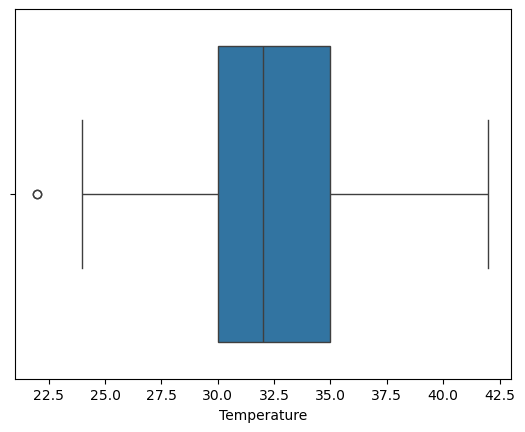

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['Temperature'])
plt.show()

In [12]:
print(df.columns.tolist())

['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']


In [16]:
Q1 = df["Temperature"].quantile(0.25)
Q3 = df["Temperature"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df["Temperature"] >= lower_limit) & (df["Temperature"] <= upper_limit)]

In [17]:
print(df.shape)

(241, 15)


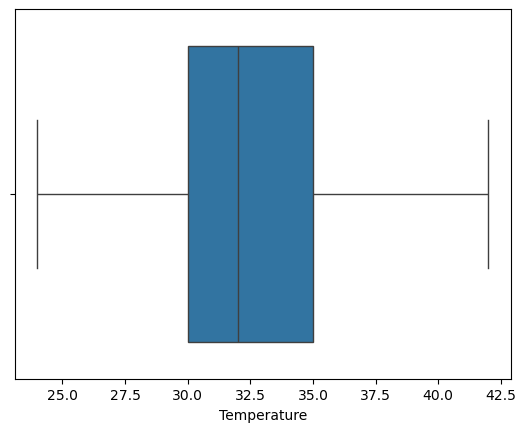

In [18]:
sns.boxplot(x=df["Temperature"])
plt.show()

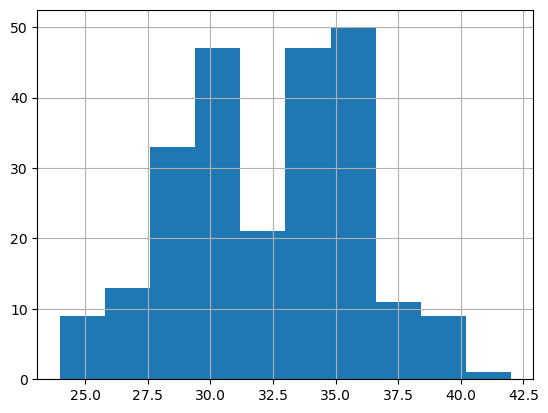

In [20]:
df["Temperature"].hist()
plt.show()

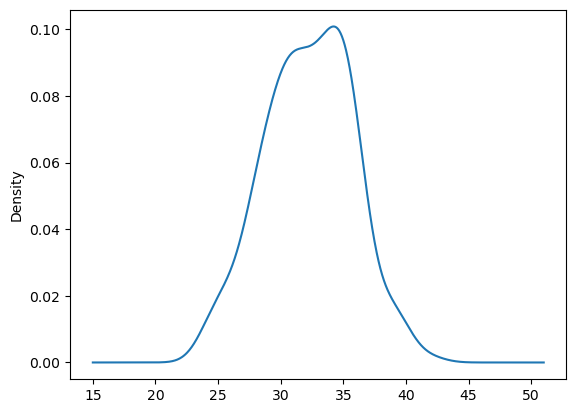

In [21]:
df["Temperature"].plot(kind="density")
plt.show()

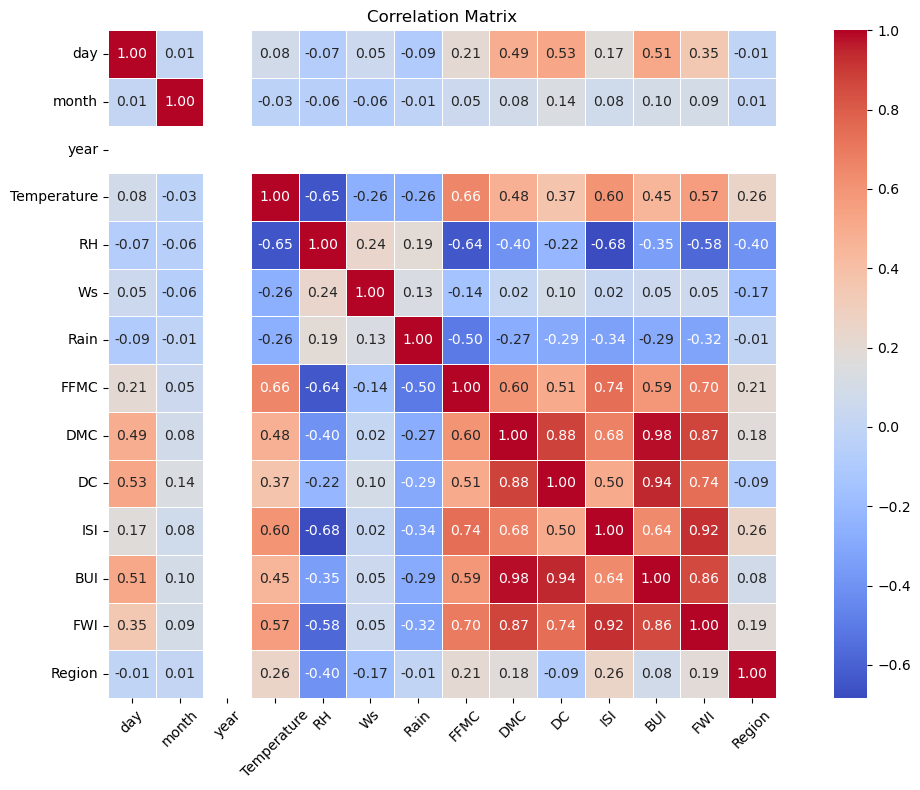

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))  
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [25]:
df.to_csv("cleaned_algerian_forest_fires.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [10]:
#Module4
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

In [11]:
df = pd.read_csv("C:\\Users\\Sri Divya\\Downloads\\Algerian forest fires.csv")

In [12]:
print(df.head())
print(df.columns)

   day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4   
1    2      6  2012           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9   
2    3      6  2012           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7   
3    4      6  2012           25  89  13   2.5  28.6  1.3   6.9  0.0  1.7   
4    5      6  2012           27  77  16   0.0  64.8  3.0  14.2  1.2  3.9   

   FWI      Classes  Region  
0  0.5  not fire          0  
1  0.4  not fire          0  
2  0.1  not fire          0  
3  0.0  not fire          0  
4  0.5  not fire          0  
Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')


In [13]:
df.columns = df.columns.str.strip()   

In [14]:
correlation_matrix = df.corr(numeric_only=True)

fwi_correlation = correlation_matrix["FWI"].sort_values(ascending=False)

print(fwi_correlation)

FWI            1.000000
ISI            0.922895
DMC            0.875864
BUI            0.857973
DC             0.739521
FFMC           0.691132
Temperature    0.566670
day            0.350781
Region         0.197102
month          0.082639
Ws             0.032368
Rain          -0.324422
RH            -0.580957
year                NaN
Name: FWI, dtype: float64


In [15]:
selected_features = fwi_correlation[abs(fwi_correlation) > 0.3].index.tolist()

if "FWI" in selected_features:
    selected_features.remove("FWI")

print("Selected Features:", selected_features)

Selected Features: ['ISI', 'DMC', 'BUI', 'DC', 'FFMC', 'Temperature', 'day', 'Rain', 'RH']


In [16]:
X = df[selected_features]
y = df["FWI"]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("Correlation with FWI:")
print(fwi_correlation)

print("\nSelected Features:")
print(selected_features)

Correlation with FWI:
FWI            1.000000
ISI            0.922895
DMC            0.875864
BUI            0.857973
DC             0.739521
FFMC           0.691132
Temperature    0.566670
day            0.350781
Region         0.197102
month          0.082639
Ws             0.032368
Rain          -0.324422
RH            -0.580957
year                NaN
Name: FWI, dtype: float64

Selected Features:
['ISI', 'DMC', 'BUI', 'DC', 'FFMC', 'Temperature', 'day', 'Rain', 'RH']


In [21]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 rows of X:")
print(X.head())

print("\nFirst 5 values of y:")
print(y.head())

Shape of X: (243, 9)
Shape of y: (243,)

First 5 rows of X:
   ISI  DMC  BUI    DC  FFMC  Temperature  day  Rain  RH
0  1.3  3.4  3.4   7.6  65.7           29    1   0.0  57
1  1.0  4.1  3.9   7.6  64.4           29    2   1.3  61
2  0.3  2.5  2.7   7.1  47.1           26    3  13.1  82
3  0.0  1.3  1.7   6.9  28.6           25    4   2.5  89
4  1.2  3.0  3.9  14.2  64.8           27    5   0.0  77

First 5 values of y:
0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64


In [22]:
print("Scaled Feature Sample:")
print(X_scaled.head())

Scaled Feature Sample:
        ISI       DMC       BUI        DC      FFMC  Temperature       day  \
0 -0.830356 -0.912120 -0.936012 -0.879401 -0.847927    -0.870655 -1.672796   
1 -0.902720 -0.855520 -0.900798 -0.879401 -0.938709    -0.870655 -1.559473   
2 -1.071571 -0.984891 -0.985310 -0.889913 -2.146802    -1.699254 -1.446150   
3 -1.143935 -1.081920 -1.055737 -0.894117 -3.438694    -1.975454 -1.332827   
4 -0.854477 -0.944463 -0.900798 -0.740651 -0.910776    -1.423054 -1.219504   

       Rain        RH  
0 -0.381657 -0.340673  
1  0.268642 -0.070359  
2  6.171355  1.348788  
3  0.868918  1.821837  
4 -0.381657  1.010896  


In [23]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nFirst 5 rows of X_train:")
print(X_train[:5])

Training set size: (194, 9)
Testing set size: (49, 9)

First 5 rows of X_train:
          ISI       DMC       BUI        DC      FFMC  Temperature       day  \
115 -0.782113 -0.742320 -0.766987 -0.719628 -0.666364    -0.870655  0.933632   
207  2.015983  3.769500  3.331860  2.475836  1.002621     0.234145  1.160278   
158 -0.154953 -0.135893 -0.210614 -0.294968  0.499830     1.615144 -0.992858   
132  2.088347  0.284563  0.092222 -0.397980  0.890889    -0.318255 -0.539566   
84   1.027001  2.087674  2.409268  2.562029  0.772175     0.510345  0.933632   

         Rain        RH  
115 -0.081519  0.199954  
207 -0.381657 -1.692242  
158 -0.131542 -1.286771  
132 -0.381657 -1.354350  
84  -0.381657  0.132376  


In [24]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully ✅")

Scaler saved successfully ✅


In [25]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pickle

In [26]:
ridge = Ridge(alpha=1.0)   # initial alpha

ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [27]:
alphas = [0.01, 0.1, 1, 10, 100]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print(f"\nAlpha: {a}")
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test R2 :", r2_score(y_test, y_test_pred))


Alpha: 0.01
Train R2: 0.9730486942094969
Test R2 : 0.9895007385496087

Alpha: 0.1
Train R2: 0.9730313222822975
Test R2 : 0.9881088657298283

Alpha: 1
Train R2: 0.972908679954487
Test R2 : 0.9828761119126189

Alpha: 10
Train R2: 0.9704997017759381
Test R2 : 0.9682200248576665

Alpha: 100
Train R2: 0.9276015050036597
Test R2 : 0.8707417804410458


In [28]:
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [29]:
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

print("Final Model Performance")
print("------------------------")
print("Training R2:", r2_score(y_train, y_train_pred))
print("Testing R2 :", r2_score(y_test, y_test_pred))

print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Testing RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Final Model Performance
------------------------
Training R2: 0.9704997017759381
Testing R2 : 0.9682200248576665
Training RMSE: 1.3378352306927805
Testing RMSE : 0.9814279808466798


In [30]:
with open("ridge.pkl", "wb") as f:
    pickle.dump(ridge, f)

print("Model saved successfully as ridge.pkl ✅")

Model saved successfully as ridge.pkl ✅


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

In [32]:
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

In [33]:
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training MAE:", train_mae)
print("Testing MAE :", test_mae)

Training MAE: 0.8133639310109888
Testing MAE : 0.6755215661405


In [34]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

Training RMSE: 1.3378352306927805
Testing RMSE : 0.9814279808466798


In [35]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R2:", train_r2)
print("Testing R2 :", test_r2)

Training R2: 0.9704997017759381
Testing R2 : 0.9682200248576665


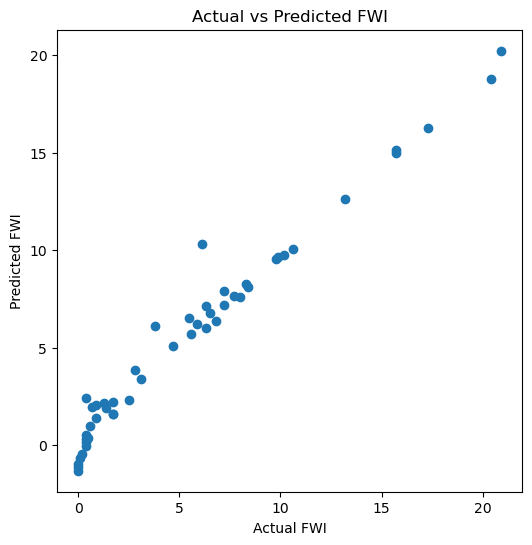

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI")
plt.show()

In [37]:
alphas = [0.01, 0.1, 1, 10, 50, 100]

best_alpha = None
best_r2 = -1

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    
    print(f"Alpha: {a} | Test R2: {score}")
    
    if score > best_r2:
        best_r2 = score
        best_alpha = a

print("\nBest Alpha:", best_alpha)

Alpha: 0.01 | Test R2: 0.9895007385496087
Alpha: 0.1 | Test R2: 0.9881088657298283
Alpha: 1 | Test R2: 0.9828761119126189
Alpha: 10 | Test R2: 0.9682200248576665
Alpha: 50 | Test R2: 0.9130863320636934
Alpha: 100 | Test R2: 0.8707417804410458

Best Alpha: 0.01


In [38]:
ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train, y_train)

print("Model retrained with optimized alpha.")

Model retrained with optimized alpha.
